# Finding fitting parameters p = {e, a2, a3, a4, a5, a6}

In [164]:
import numpy as np

# Set up matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

from astropy.io import fits
from scipy.ndimage import gaussian_filter, shift as nd_shift, zoom
from astropy.stats import sigma_clipped_stats
from scipy.ndimage import binary_closing, binary_opening

from pathlib import Path
import json

In [165]:
hdu_list = fits.open("data/Focus_r_2025-05-05T21-18-55.fits")
hdu_list.info()

Filename: data/Focus_r_2025-05-05T21-18-55.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (2048, 2048)   int16 (rescales to uint16)   


In [166]:
header = hdu_list[0].header
header

SIMPLE  =                    T / C# FITS: 05.05.2025 21:19:20                   
BITPIX  =                   16                                                  
NAXIS   =                    2 / Dimensionality                                 
NAXIS1  =                 2048                                                  
NAXIS2  =                 2048                                                  
PMLS    =                    F / prim minus lim switch activated                
PPLS    =                    F / prim plus lim switch activated                 
TRACKING=                    T / is mount tracking                              
COMFAULT=                    F / com fault between sitech and brush             
INIT    =                    T / is mount initialized                           
SLEWING =                    F / is mount slewing                               
LOOKEAST=                    F / is mount looking east (GEM)                    
SPLS    =                   

In [167]:
crop_dir = Path("processed/crops/Focus_r_2025-05-05T21-18-55_x1596_y1688_64")
raw_crop_path = crop_dir / "raw.fits"
metadata_path = crop_dir / "metadata.json"

crop_header = fits.getheader(raw_crop_path)

with open(metadata_path, "r", encoding="utf-8") as file:
    crop_metadata = json.load(file)

parent_fits_path = Path(crop_metadata["parent_fits"])
parent_header = fits.getheader(parent_fits_path) if parent_fits_path.exists() else crop_header


def header_lookup(keys, default=None):
    """Look in the crop header first, then the parent FITS header."""
    for source_name, header in [("crop", crop_header), ("parent", parent_header)]:
        for key in keys:
            if key in header:
                return {
                    "value": header[key],
                    "header_key": key,
                    "source": source_name,
                    "comment": header.comments[key],
                }
    return {
        "value": default,
        "header_key": None,
        "source": None,
        "comment": "not found in crop or parent FITS header",
    }


observing_metadata = {
    "focus": header_lookup(["FOCUS"]),
    "exptime_s": header_lookup(["EXPTIME"]),
    "filter": header_lookup(["FILTER"]),
    "seeing_arcsec": header_lookup(["SEEING"]),
    "gain_e_per_adu": header_lookup(["GAIN"]),
    "read_noise_e": header_lookup(["RDNOISE"]),
    "x_binning": header_lookup(["XBINNING"]),
    "y_binning": header_lookup(["YBINNING"]),
    "pixel_size_x_um": header_lookup(["XPIXSZ", "PIXSIZE", "PIXSZ"]),
    "pixel_size_y_um": header_lookup(["YPIXSZ", "PIXSIZE", "PIXSZ"]),
    "telescope": header_lookup(["TELESCOP"]),
    "instrument": header_lookup(["INSTRUME"]),
}


# Required for calibrated DONUT coefficients, but not present in this FITS header.
# Fill these only from verified instrument documentation/calibration.
physical_calibration = {
    "telescope_diameter_m": header_lookup(["DIAMETER", "APTDIA", "APERTURE", "TELDIAM"]),
    "plate_scale_arcsec_per_pixel": header_lookup(["PIXSCALE", "SECPIX", "PLTSCALE"]),
    "lambda_eff_m": header_lookup(["EFFWAVE", "WAVELEN", "LAMBDA"]),
    "central_obstruction_ratio": header_lookup(["OBSCURE", "OBSRATIO", "CENTOBS"]),
}

instrument_metadata = {
    "raw_crop_path": str(raw_crop_path),
    "parent_fits_path": str(parent_fits_path),
    "crop_metadata": crop_metadata,
    "observing_metadata": observing_metadata,
    "physical_calibration": physical_calibration,
}


print("Observed FITS/header values")
for name, item in observing_metadata.items():
    print(f"{name:28s}: {item['value']}  [{item['header_key']} from {item['source']}]")

print("\nPhysical calibration values for DONUT model")
for name, item in physical_calibration.items():
    print(f"{name:28s}: {item['value']}  ({item['comment']})")

# Convenient scalar variables for later cells
focus = observing_metadata["focus"]["value"]
exptime_s = observing_metadata["exptime_s"]["value"]
filter_name = observing_metadata["filter"]["value"]
seeing_arcsec = observing_metadata["seeing_arcsec"]["value"]
gain_e_per_adu = observing_metadata["gain_e_per_adu"]["value"]
read_noise_e = observing_metadata["read_noise_e"]["value"]
x_binning = observing_metadata["x_binning"]["value"]
y_binning = observing_metadata["y_binning"]["value"]
pixel_size_x_um = observing_metadata["pixel_size_x_um"]["value"]
pixel_size_y_um = observing_metadata["pixel_size_y_um"]["value"]

telescope_diameter_m = physical_calibration["telescope_diameter_m"]["value"]
plate_scale_arcsec_per_pixel = physical_calibration["plate_scale_arcsec_per_pixel"]["value"]
lambda_eff_m = physical_calibration["lambda_eff_m"]["value"]
central_obstruction_ratio = physical_calibration["central_obstruction_ratio"]["value"]

Observed FITS/header values
focus                       : 15339  [FOCUS from crop]
exptime_s                   : 20  [EXPTIME from crop]
filter                      : r  [FILTER from crop]
seeing_arcsec               : 3.86  [SEEING from crop]
gain_e_per_adu              : 1.4  [GAIN from crop]
read_noise_e                : 14  [RDNOISE from crop]
x_binning                   : 1  [XBINNING from crop]
y_binning                   : 1  [YBINNING from crop]
pixel_size_x_um             : 13.5  [XPIXSZ from crop]
pixel_size_y_um             : 13.5  [YPIXSZ from crop]
telescope                   : APM-RoboPhot  [TELESCOP from crop]
instrument                  : TRIP  [INSTRUME from crop]

Physical calibration values for DONUT model
telescope_diameter_m        : None  (not found in crop or parent FITS header)
plate_scale_arcsec_per_pixel: None  (not found in crop or parent FITS header)
lambda_eff_m                : None  (not found in crop or parent FITS header)
central_obstruction_ratio   : N

The next cells build a background-noise mask for the raw 64 x 64 crop. `np.indices(raw.shape)` creates two coordinate images: `yy` contains the row/y coordinate of every pixel and `xx` contains the column/x coordinate of every pixel. `x0` and `y0` are the geometric center of the crop. `np.hypot(xx - x0, yy - y0)` calculates each pixel's radial distance from that center in pixels, so later we can select circular regions such as an outer background annulus or an inner fit region.

`background_mask` selects finite pixels in the annulus `24 <= r <= 30`. This is meant to sample local sky/background away from most of the donut signal. `sigma_clipped_stats(raw[background_mask], sigma=1.0, maxiters=5)` estimates robust background statistics from those annulus pixels. The function repeatedly computes statistics, rejects values farther than `sigma` standard deviations from the current center, and recomputes until it stabilizes or reaches `maxiters`. It returns mean, median, and standard deviation; here `_` ignores the mean, `background_adu` is the sigma-clipped median, and `background_rms_adu` is the sigma-clipped standard deviation/noise estimate. `signal = raw - background_adu` subtracts that background level from the crop.

`threshold_adu = threshold_sigma * background_rms_adu` converts the noise estimate into an ADU cutoff. For example, `threshold_sigma = 1` keeps pixels more than one background RMS above the background-subtracted zero level. Lower values keep more faint donut pixels but also more noise; higher values remove more noise but can cut away weak real signal. `fit_region = r <= 28.0` prevents the mask from using outer edge pixels, and `source_mask_initial` keeps only finite pixels inside that region with signal above the threshold.

`structure = np.ones((4, 4), dtype=bool)` says that cleanup operations should look at each pixel and its local 4 x 4 neighborhood. `binary_opening` removes tiny isolated bright noise islands by eroding then dilating the mask. `binary_closing` fills small holes and joins very small gaps by dilating then eroding. If this cleanup removes almost everything, the `if fit_mask.sum() < 20` fallback restores the direct threshold mask. The printed lines are only diagnostics: background level, background RMS, threshold, and how many pixels remain in the mask.

In [168]:
# Background-noise mask for the raw 64x64 crop.
# This cell does NOT normalize the image.
raw_crop_path = Path("processed/crops/Focus_r_2025-05-05T21-18-55_x1596_y1688_64/raw.fits")
raw = fits.getdata(raw_crop_path).astype(np.float64)

In [169]:
ny, nx = raw.shape
yy, xx = np.indices(raw.shape)
x0 = (nx - 1) / 2.0
y0 = (ny - 1) / 2.0
r = np.hypot(xx - x0, yy - y0)

In [170]:
# Estimate background from an outer annulus, away from the donut signal.
background_mask = (
    np.isfinite(raw)
    & (r >= 24.0)
    & (r <= 30.0)
)

_, background_adu, background_rms_adu = sigma_clipped_stats(
    raw[background_mask],
    sigma=1.0,
    maxiters=5,
)

signal = raw - background_adu

In [171]:
# lower = keeps fainter donut pixels, higher = removes more background noise.
threshold_sigma = 1.0
threshold_adu = threshold_sigma * background_rms_adu

fit_region = r <= 28.0
source_mask_initial = (
    np.isfinite(signal)
    & fit_region
    & (signal > threshold_adu)
)

In [172]:
# Remove tiny isolated noise islands while keeping the donut shape.
structure = np.ones((4, 4), dtype=bool)
fit_mask = binary_opening(source_mask_initial, structure=structure)
fit_mask = binary_closing(fit_mask, structure=structure)

# If cleaning was too aggressive, fall back to the direct threshold mask.
if fit_mask.sum() < 20:
    fit_mask = source_mask_initial

print(f"Background       : {background_adu:.3f} ADU")
print(f"Background RMS   : {background_rms_adu:.3f} ADU")
print(f"Threshold        : {threshold_adu:.3f} ADU above background ({threshold_sigma} sigma)")
print(f"Masked pixels    : {fit_mask.sum()} / {fit_mask.size}")

Background       : 1074.000 ADU
Background RMS   : 4.495 ADU
Threshold        : 4.495 ADU above background (1.0 sigma)
Masked pixels    : 2159 / 4096


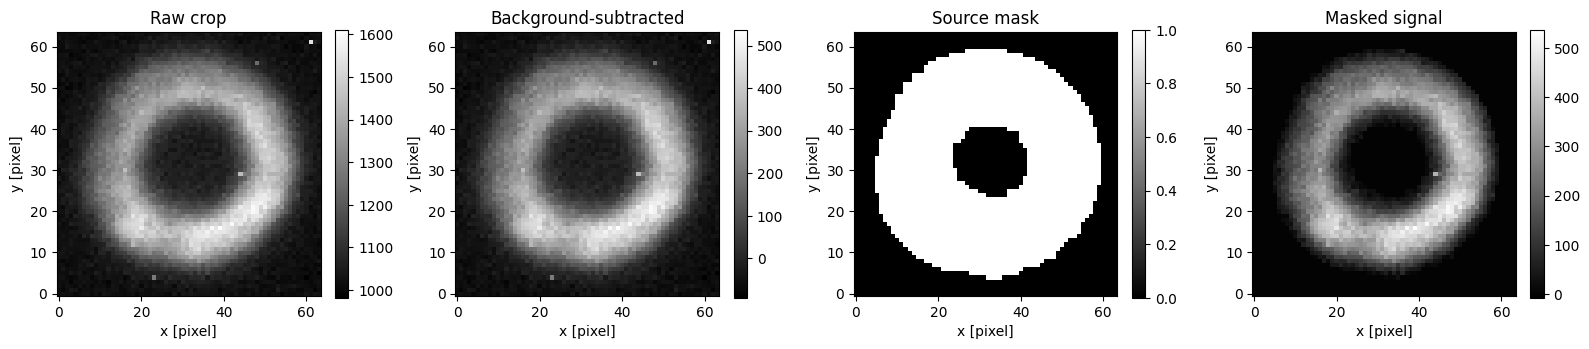

In [173]:
masked_signal = np.where(fit_mask, signal, 0.0)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

im0 = ax[0].imshow(raw, origin="lower", cmap="gray")
ax[0].set_title("Raw crop")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(signal, origin="lower", cmap="gray")
ax[1].set_title("Background-subtracted")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(fit_mask, origin="lower", cmap="gray")
ax[2].set_title("Source mask")
plt.colorbar(im2, ax=ax[2], fraction=0.046)

im3 = ax[3].imshow(masked_signal, origin="lower", cmap="gray")
ax[3].set_title("Masked signal")
plt.colorbar(im3, ax=ax[3], fraction=0.046)

for axis in ax:
    axis.set_xlabel("x [pixel]")
    axis.set_ylabel("y [pixel]")

plt.tight_layout()
plt.show()

In [174]:
Iij_moments = np.where(
    fit_mask,
    np.clip(signal, 0.0, None),
    0.0,
)

I0_moments = Iij_moments.sum()
if I0_moments <= 0 or not np.isfinite(I0_moments):
    raise RuntimeError("The masked crop has no positive flux for moment calculation.")

# Pixel-coordinate grids
yy, xx = np.indices(Iij_moments.shape)

# Equation (4): centroid coordinates
x_c = np.sum(xx * Iij_moments) / I0_moments
y_c = np.sum(yy * Iij_moments) / I0_moments

# Equation (4): second moments
Mx = np.sum((xx - x_c)**2 * Iij_moments) / I0_moments
My = np.sum((yy - y_c)**2 * Iij_moments) / I0_moments
Mxy = np.sum((xx - x_c) * (yy - y_c) * Iij_moments) / I0_moments


In [175]:
# Observed donut image for comparison with a unit-flux model.
# It has the same preprocessing used to calculate I0, centroid, and moments.
obs_norm = Iij_moments / I0_moments

print("Observed-image shape:", obs_norm.shape)
print("Observed normalized flux:", obs_norm.sum())

Observed-image shape: (64, 64)
Observed normalized flux: 1.0


In [176]:
print("Zero-Order moment")
print("I0:", I0_moments, "ADU")
print("First Moments (centroid)")
print(f"x_c = {x_c:.3f} pixels")
print(f"y_c = {y_c:.3f} pixels")
print("Second Moments")
print(f"Mx: {Mx:.3f} pixels^2")
print(f"My: {My:.3f} pixels^2")
print(f"Mxy: {Mxy:.3f} pixels^2")

Zero-Order moment
I0: 472339.0 ADU
First Moments (centroid)
x_c = 33.480 pixels
y_c = 30.172 pixels
Second Moments
Mx: 189.374 pixels^2
My: 195.113 pixels^2
Mxy: 9.100 pixels^2


In [177]:
# Fixed instrument configuration used by the physical DONUT model.
D_primary_mm = 600.0
D_secondary_mm = 250.0
eta = D_secondary_mm / D_primary_mm

plate_scale_arcsec_px = 0.65
lambda_mm = 6.165e-4  # adopted nominal SDSS-r effective wavelength: 616.5 nm

seeing_fwhm_arcsec_0 = 3.86
seeing_fwhm_px_0 = seeing_fwhm_arcsec_0 / plate_scale_arcsec_px
seeing_sigma_px_0 = seeing_fwhm_px_0 / 2.355

# Compatibility names used by the moment equations below.
D = D_primary_mm
D_secondary = D_secondary_mm
p = plate_scale_arcsec_px

# Calculating the initial DONUT angular quantities from the second moments.
# These are starting estimates only; the forward model below determines the image shape.
A4 = p * np.sqrt((Mx + My) / 2.0)  # arcseconds
A5 = p * Mxy * (Mx * My) ** -0.25  # arcseconds
A6 = 0.5 * p * (Mx - My) * (Mx * My) ** -0.25  # arcseconds


In [178]:
print(f"A4 = {A4:.3f} arcseconds")
print(f"A5 = {A5:.3f} arcseconds")
print(f"A6 = {A6:.3f} arcseconds")

A4 = 9.012 arcseconds
A5 = 0.427 arcseconds
A6 = -0.135 arcseconds


In [179]:
# Let Mx = My = rho^2 / 4
# Therefore, A4 = p * rho / 2
rho = 2 * A4
print(f"rho = {rho:.3f} arcseconds")

rho = 18.025 arcseconds


In [180]:
print(f"D_primary_mm        = {D_primary_mm:.1f} mm")
print(f"D_secondary_mm      = {D_secondary_mm:.1f} mm")
print(f"eta                 = {eta:.6f}")
print(f"plate scale         = {plate_scale_arcsec_px:.3f} arcsec/pixel")
print(f"lambda              = {lambda_mm:.7g} mm")
print(f"seeing FWHM         = {seeing_fwhm_arcsec_0:.2f} arcsec")
print(f"seeing sigma        = {seeing_sigma_px_0:.3f} pixels")


D_primary_mm        = 600.0 mm
D_secondary_mm      = 250.0 mm
eta                 = 0.416667
plate scale         = 0.650 arcsec/pixel
lambda              = 0.0006165 mm
seeing FWHM         = 3.86 arcsec
seeing sigma        = 2.522 pixels


In [181]:
# Convert rho from arcseconds to radians
rho_rad = rho * (np.pi / 180.0) / 3600.0

# Convert A5 and A6 from arcseconds to radians
A4_rad = A4 * (np.pi / 180.0) / 3600.0
A5_rad = A5 * (np.pi / 180.0) / 3600.0
A6_rad = A6 * (np.pi / 180.0) / 3600.0

In [214]:
# Initial estimates of defocus and astigmatism.
# These moment-derived values seed the physical forward model; they are not final fitted coefficients.
a4_0 = rho_rad * D / (8 * np.sqrt(3))
a5_0 = A5_rad * D / 0.23
a6_0 = A6_rad * D / 0.23

print(f"Initial Zernike coefficient (defocus) (a4): {a4_0:.10f} mm || {a4_0 * 1000 :.3f} µm")
print(f"Initial Zernike coefficient (Astigmatism 45 deg) (a5): {a5_0:.10f} mm || {a5_0 * 1000 :.3f} µm")
print(f"Initial Zernike coefficient (Astigmatism perpendicular) (a6): {a6_0:.10f} mm || {a6_0 * 1000 :.3f} µm")


Initial Zernike coefficient (defocus) (a4): 0.0037839436 mm || 3.784 µm
Initial Zernike coefficient (Astigmatism 45 deg) (a5): 0.0053956821 mm || 5.396 µm
Initial Zernike coefficient (Astigmatism perpendicular) (a6): -0.0017015505 mm || -1.702 µm


In [215]:
print(f"Initial Zernike coefficient (defocus) (a4): {a4_0:.10f} mm || {a4_0 * 1000 :.3f} µm")
print(f"Initial Zernike coefficient (Astigmatism 45 deg) (a5): {0:.3f} mm || {0 * 1000 :.3f} µm")
print(f"Initial Zernike coefficient (Astigmatism perpendicular) (a6): {0:.3f} mm || {0 * 1000 :.3f} µm")

Initial Zernike coefficient (defocus) (a4): 0.0037839436 mm || 3.784 µm
Initial Zernike coefficient (Astigmatism 45 deg) (a5): 0.000 mm || 0.000 µm
Initial Zernike coefficient (Astigmatism perpendicular) (a6): 0.000 mm || 0.000 µm


Checking if the a4 value is the same

In [183]:
print(f"{(A4_rad * D / (4 * np.sqrt(3))) * 1000:.10f} um")
print(f"Initial Zernike coefficient (defocus) (a4): {a4_0:.10f} mm || {a4_0 * 1000 :.3f} um")


3.7839435920 um
Initial Zernike coefficient (defocus) (a4): 0.0037839436 mm || 3.784 um


From here forward, the moment results are only starting values. The model image is generated physically: annular pupil -> Zernike wavefront -> FFT point-spread image -> seeing convolution -> detector binning -> image shift. The validation cells compare that model against the observed masked donut before any Appendix-A finite-difference iteration is allowed to run.


In [184]:
# Physical pupil and FFT sampling.
detector_shape = obs_norm.shape
if detector_shape[0] != detector_shape[1]:
    raise ValueError("This forward-model cell expects a square crop.")

fft_grid_size = 1024
detector_oversampling = 4
arcsec_per_radian = 206264.80624709636

# Fraunhofer FFT angular sampling for a pupil grid spanning the primary diameter.
fft_image_arcsec_per_px = (lambda_mm / D_primary_mm) * arcsec_per_radian
detector_window_fft_px = int(
    np.round(detector_shape[0] * plate_scale_arcsec_px / fft_image_arcsec_per_px)
)

# Keep the crop symmetric around the FFT origin.
if detector_window_fft_px % 2:
    detector_window_fft_px += 1

if detector_window_fft_px >= fft_grid_size:
    raise ValueError(
        "Increase fft_grid_size: the detector field of view is larger than the FFT grid."
    )

pupil_axis = (np.arange(fft_grid_size) - fft_grid_size / 2) / (fft_grid_size / 2)
pupil_x, pupil_y = np.meshgrid(pupil_axis, pupil_axis)
rho_norm = np.hypot(pupil_x, pupil_y)
theta = np.arctan2(pupil_y, pupil_x)

pupil = (rho_norm <= 1.0) & (rho_norm >= eta)

# Noll low-order Zernike terms used here: defocus and two astigmatisms.
Z4 = np.where(pupil, np.sqrt(3.0) * (2.0 * rho_norm**2 - 1.0), 0.0)
Z5 = np.where(pupil, np.sqrt(6.0) * rho_norm**2 * np.sin(2.0 * theta), 0.0)
Z6 = np.where(pupil, np.sqrt(6.0) * rho_norm**2 * np.cos(2.0 * theta), 0.0)

print(f"FFT grid: {fft_grid_size} x {fft_grid_size}")
print(f"FFT image scale: {fft_image_arcsec_per_px:.4f} arcsec/FFT pixel")
print(f"Detector crop: {detector_shape[0]} pixels = {detector_shape[0] * plate_scale_arcsec_px:.2f} arcsec")
print(f"Central FFT window used for detector crop: {detector_window_fft_px} x {detector_window_fft_px}")


FFT grid: 1024 x 1024
FFT image scale: 0.2119 arcsec/FFT pixel
Detector crop: 64 pixels = 41.60 arcsec
Central FFT window used for detector crop: 196 x 196


In [185]:
def center_crop_square(image, size):
    """Return a centered square crop with the requested size."""
    cy, cx = np.array(image.shape) // 2
    half = size // 2
    return image[cy - half:cy + half, cx - half:cx + half]


def match_shape_centered(image, target_shape):
    """Center-crop or center-pad an array to exactly target_shape."""
    target_y, target_x = target_shape
    out = np.zeros(target_shape, dtype=image.dtype)

    copy_y = min(target_y, image.shape[0])
    copy_x = min(target_x, image.shape[1])

    src_y0 = (image.shape[0] - copy_y) // 2
    src_x0 = (image.shape[1] - copy_x) // 2
    dst_y0 = (target_y - copy_y) // 2
    dst_x0 = (target_x - copy_x) // 2

    out[dst_y0:dst_y0 + copy_y, dst_x0:dst_x0 + copy_x] = image[
        src_y0:src_y0 + copy_y,
        src_x0:src_x0 + copy_x,
    ]
    return out


def bin_oversampled_to_detector(image_over, oversampling):
    """Integrate oversampling x oversampling samples into one detector pixel."""
    ny_over, nx_over = image_over.shape
    if ny_over % oversampling or nx_over % oversampling:
        raise ValueError("Oversampled image shape must divide evenly by oversampling.")

    return image_over.reshape(
        ny_over // oversampling,
        oversampling,
        nx_over // oversampling,
        oversampling,
    ).sum(axis=(1, 3))


def render_model(params, fit_mask=None, return_debug=False):
    """
    Physical DONUT forward model with detector-scale normalization.

    params keys:
    seeing_sigma_px, dx_px, dy_px, a4_mm, a5_mm, a6_mm
    """
    wavefront_mm = (
        params.get("a4_mm", 0.0) * Z4
        + params.get("a5_mm", 0.0) * Z5
        + params.get("a6_mm", 0.0) * Z6
    )

    phase = 2.0 * np.pi * wavefront_mm / lambda_mm
    complex_pupil = pupil.astype(float) * np.exp(1j * phase)

    field = np.fft.fftshift(
        np.fft.fft2(
            np.fft.ifftshift(complex_pupil)
        )
    )
    image_fft = np.abs(field)**2
    image_fft /= image_fft.sum()

    # Convert the FFT angular scale to an oversampled detector grid.
    image_window = center_crop_square(image_fft, detector_window_fft_px)
    target_over_shape = (
        detector_shape[0] * detector_oversampling,
        detector_shape[1] * detector_oversampling,
    )
    zoom_factors = (
        target_over_shape[0] / image_window.shape[0],
        target_over_shape[1] / image_window.shape[1],
    )
    image_over = zoom(image_window, zoom_factors, order=1)
    image_over = match_shape_centered(image_over, target_over_shape)
    image_over = np.clip(image_over, 0.0, None)
    image_over /= image_over.sum()

    seeing_sigma_over = params.get("seeing_sigma_px", 0.0) * detector_oversampling
    if seeing_sigma_over > 0:
        image_over = gaussian_filter(
            image_over,
            sigma=seeing_sigma_over,
            mode="constant",
            cval=0.0,
        )
        image_over /= image_over.sum()

    model_det = bin_oversampled_to_detector(image_over, detector_oversampling)

    model_det = nd_shift(
        model_det,
        shift=(params.get("dy_px", 0.0), params.get("dx_px", 0.0)),
        order=3,
        mode="constant",
        cval=0.0,
        prefilter=True,
    )
    model_det = np.clip(model_det, 0.0, None)

    if fit_mask is None:
        norm = model_det.sum()
    else:
        norm = model_det[fit_mask].sum()

    if norm <= 0 or not np.isfinite(norm):
        raise RuntimeError("Invalid model normalization.")

    model_det = model_det / norm

    if return_debug:
        return model_det, {
            "wavefront_mm": wavefront_mm,
            "image_fft": image_fft,
            "image_window": image_window,
            "image_over": image_over,
            "fft_image_arcsec_per_px": fft_image_arcsec_per_px,
            "detector_window_fft_px": detector_window_fft_px,
        }

    return model_det


In [186]:
# Moment-derived initial parameter vectors.
crop_center_x = (detector_shape[1] - 1) / 2.0
crop_center_y = (detector_shape[0] - 1) / 2.0

dx_0 = x_c - crop_center_x
dy_0 = y_c - crop_center_y

moment_initial_params = {
    "seeing_sigma_px": seeing_sigma_px_0,
    "dx_px": dx_0,
    "dy_px": dy_0,
    "a4_mm": a4_0,
    "a5_mm": a5_0,
    "a6_mm": a6_0,
}

# The current crop's moment astigmatism is tested, not trusted blindly.
defocus_start_params = dict(moment_initial_params)
defocus_start_params["a5_mm"] = 0.0
defocus_start_params["a6_mm"] = 0.0

model_defocus_start, model_debug = render_model(
    defocus_start_params,
    fit_mask=fit_mask,
    return_debug=True,
)
model_moment_start = render_model(moment_initial_params, fit_mask=fit_mask)

print("Moment-derived full start")
for name, value in moment_initial_params.items():
    print(f"{name:16s}: {value:.8g}")

print("\nDefocus-only validation start")
for name, value in defocus_start_params.items():
    print(f"{name:16s}: {value:.8g}")


Moment-derived full start
seeing_sigma_px : 2.5216397
dx_px           : 1.9800345
dy_px           : -1.3279816
a4_mm           : 0.0037839436
a5_mm           : 0.0053956821
a6_mm           : -0.0017015505

Defocus-only validation start
seeing_sigma_px : 2.5216397
dx_px           : 1.9800345
dy_px           : -1.3279816
a4_mm           : 0.0037839436
a5_mm           : 0
a6_mm           : 0


In [187]:
def radial_mean_profile(image, center_x, center_y, mask=None, dr=1.0, r_max=None):
    yy, xx = np.indices(image.shape)
    rr = np.hypot(xx - center_x, yy - center_y)

    if r_max is None:
        r_values = rr[mask] if mask is not None else rr.ravel()
        r_max = np.nanmax(r_values)

    edges = np.arange(0.0, r_max + dr, dr)
    if len(edges) < 2:
        edges = np.array([0.0, dr])

    bin_index = np.digitize(rr.ravel(), edges) - 1
    valid = (
        (bin_index >= 0)
        & (bin_index < len(edges) - 1)
        & np.isfinite(image).ravel()
    )
    if mask is not None:
        valid &= mask.ravel()

    sums = np.bincount(
        bin_index[valid],
        weights=image.ravel()[valid],
        minlength=len(edges) - 1,
    )
    counts = np.bincount(bin_index[valid], minlength=len(edges) - 1)

    profile = np.divide(
        sums,
        counts,
        out=np.full(len(edges) - 1, np.nan, dtype=float),
        where=counts > 0,
    )
    radii = 0.5 * (edges[:-1] + edges[1:])
    return radii, profile


def peak_radius_px(image, center_x, center_y, mask=None):
    radii, profile = radial_mean_profile(image, center_x, center_y, mask=mask)
    if np.all(~np.isfinite(profile)):
        return np.nan
    return radii[np.nanargmax(profile)]


def center_to_peak_ratio(image, center_x, center_y, mask=None):
    cx_i = int(np.clip(np.round(center_x), 0, image.shape[1] - 1))
    cy_i = int(np.clip(np.round(center_y), 0, image.shape[0] - 1))

    if mask is None:
        peak = np.nanmax(image)
    else:
        peak = np.nanmax(np.where(mask, image, np.nan))

    if peak <= 0 or not np.isfinite(peak):
        return np.nan
    return image[cy_i, cx_i] / peak


def relative_residual_q(observed, model, mask):
    obs_vec = observed[mask].ravel()
    model_vec = model[mask].ravel()
    return np.sqrt(
        np.sum((obs_vec - model_vec)**2)
        / np.sum(obs_vec**2)
    )


def model_metrics(model, label):
    return {
        "label": label,
        "q": relative_residual_q(obs_norm, model, fit_mask),
        "peak_radius_px": peak_radius_px(model, x_c, y_c, mask=fit_mask),
        "center_to_peak": center_to_peak_ratio(model, x_c, y_c, mask=fit_mask),
    }


obs_peak_radius_px = peak_radius_px(obs_norm, x_c, y_c, mask=fit_mask)
defocus_metrics = model_metrics(model_defocus_start, "defocus-only")
moment_metrics = model_metrics(model_moment_start, "full moment")


def model_shape_is_usable(metrics, observed_peak_radius):
    return (
        np.isfinite(metrics["q"])
        and metrics["q"] < 0.8
        and np.isfinite(metrics["peak_radius_px"])
        and abs(metrics["peak_radius_px"] - observed_peak_radius) <= 5.0
        and metrics["center_to_peak"] < 0.45
    )


moment_start_ok = model_shape_is_usable(moment_metrics, obs_peak_radius_px)
defocus_start_ok = model_shape_is_usable(defocus_metrics, obs_peak_radius_px)

if moment_start_ok:
    appendix_start_params = dict(moment_initial_params)
    appendix_start_label = "full moment start"
elif defocus_start_ok:
    appendix_start_params = dict(defocus_start_params)
    appendix_start_label = "defocus-only start; moment astigmatism held for later fitting"
else:
    appendix_start_params = None
    appendix_start_label = "no validated start"

donut_model_validated = appendix_start_params is not None

print(f"Observed radial peak radius: {obs_peak_radius_px:.2f} px")
for metrics in [defocus_metrics, moment_metrics]:
    print(
        f"{metrics['label']:14s} | "
        f"Q = {metrics['q']:.3f}, "
        f"peak radius = {metrics['peak_radius_px']:.2f} px, "
        f"center/peak = {metrics['center_to_peak']:.3f}"
    )

print(f"\nValidated for Appendix-A start: {donut_model_validated}")
print(f"Selected start: {appendix_start_label}")


Observed radial peak radius: 18.50 px
defocus-only   | Q = 0.372, peak radius = 20.50 px, center/peak = 0.067
full moment    | Q = 1.866, peak radius = 6.50 px, center/peak = 0.612

Validated for Appendix-A start: True
Selected start: defocus-only start; moment astigmatism held for later fitting


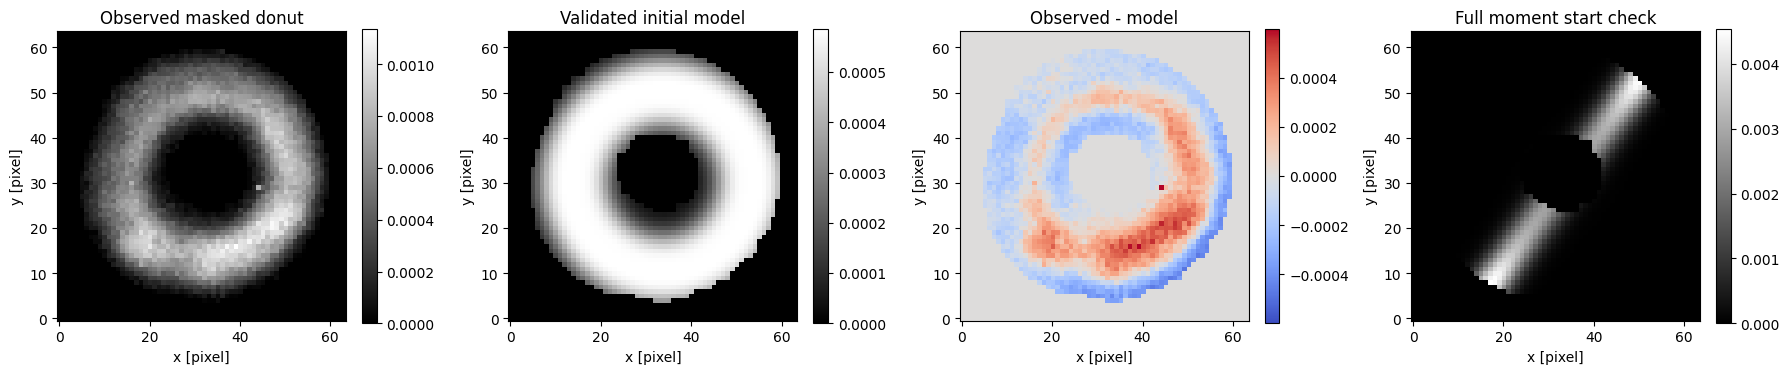

In [188]:
if donut_model_validated:
    model_initial = render_model(appendix_start_params, fit_mask=fit_mask)
    model_initial_masked = np.where(fit_mask, model_initial, 0.0)
    model_moment_masked = np.where(fit_mask, model_moment_start, 0.0)
    residual_initial = obs_norm - model_initial_masked

    fig, ax = plt.subplots(1, 4, figsize=(18, 4))

    im0 = ax[0].imshow(obs_norm, origin="lower", cmap="gray")
    ax[0].set_title("Observed masked donut")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(model_initial_masked, origin="lower", cmap="gray")
    ax[1].set_title("Validated initial model")
    plt.colorbar(im1, ax=ax[1], fraction=0.046)

    lim = np.nanmax(np.abs(residual_initial[fit_mask]))
    if not np.isfinite(lim) or lim == 0:
        lim = 1.0

    im2 = ax[2].imshow(
        residual_initial,
        origin="lower",
        cmap="coolwarm",
        vmin=-lim,
        vmax=lim,
    )
    ax[2].set_title("Observed - model")
    plt.colorbar(im2, ax=ax[2], fraction=0.046)

    im3 = ax[3].imshow(model_moment_masked, origin="lower", cmap="gray")
    ax[3].set_title("Full moment start check")
    plt.colorbar(im3, ax=ax[3], fraction=0.046)

    for axis in ax:
        axis.set_xlabel("x [pixel]")
        axis.set_ylabel("y [pixel]")

    plt.tight_layout()
    plt.show()
else:
    print("The initial physical model is not close enough. Do not run Appendix-A iterations yet.")


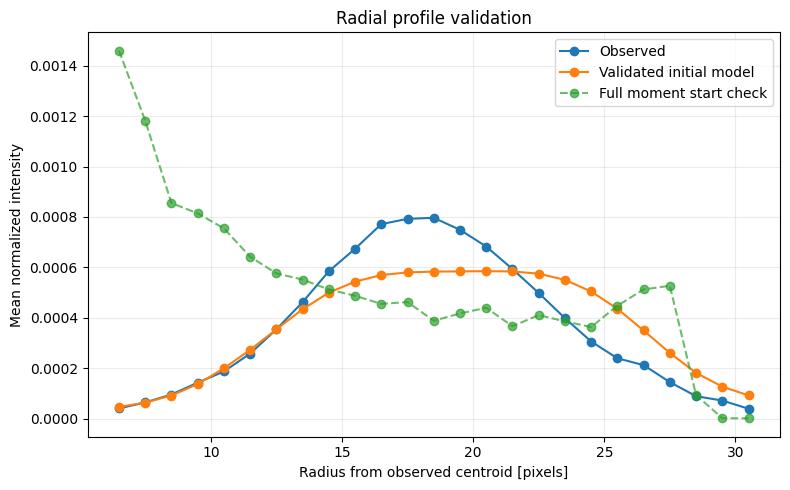

In [189]:
if donut_model_validated:
    r_obs, prof_obs = radial_mean_profile(obs_norm, x_c, y_c, mask=fit_mask)
    r_model, prof_model = radial_mean_profile(model_initial, x_c, y_c, mask=fit_mask)
    r_moment, prof_moment = radial_mean_profile(model_moment_start, x_c, y_c, mask=fit_mask)

    plt.figure(figsize=(8, 5))
    plt.plot(r_obs, prof_obs, "o-", label="Observed")
    plt.plot(r_model, prof_model, "o-", label="Validated initial model")
    plt.plot(r_moment, prof_moment, "o--", label="Full moment start check", alpha=0.7)
    plt.xlabel("Radius from observed centroid [pixels]")
    plt.ylabel("Mean normalized intensity")
    plt.title("Radial profile validation")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


Appendix A builds an interaction matrix from finite model differences. Each column is `(M(a + delta_j) - M(a)) / delta_j`; the pseudoinverse maps the residual vector `(I - M)` into a parameter correction. The code below prepares that machinery, including the paper's damped update idea, but it does not run the loop automatically. Run it only after `donut_model_validated` is `True` and the plots above show an annular donut rather than a streak or stripe.


In [209]:
# Parameters fitted by the Appendix-A interaction-matrix algorithm.
# The current start model is deliberately astigmatism-free: a5_mm = 0 and a6_mm = 0.
# If fit_astigmatism=True in donut_algorithm(), the iteration is still allowed to move
# a5_mm and a6_mm away from zero when the observed donut shape needs astigmatism.
fit_parameter_names = [
    "seeing_sigma_px",
    "dx_px",
    "dy_px",
    "a4_mm",
    "a5_mm",
    "a6_mm",
]

# Appendix A changes seeing by 0.1 arcsec. Convert that to Gaussian sigma in detector pixels.
seeing_step_sigma_px = (0.1 / plate_scale_arcsec_px) / 2.355

# Appendix A suggests a small Zernike phase step of 0.5 / n radians.
# For Z4-Z6, n = 2. Our Zernike coefficients are optical path difference in mm,
# so phase = 2*pi*OPD/lambda gives OPD_step = lambda*phase_step/(2*pi).
zernike_step_n2_mm = lambda_mm * (0.5 / 2.0) / (2.0 * np.pi)

# Finite-difference steps for the interaction matrix columns.
appendix_a_steps = {
    "seeing_sigma_px": seeing_step_sigma_px,
    "dx_px": 0.10,
    "dy_px": 0.10,
    "a4_mm": zernike_step_n2_mm,
    "a5_mm": zernike_step_n2_mm,
    "a6_mm": zernike_step_n2_mm,
}

# Explicit astigmatism-free initial parameters for the current version.
donut_start_params = dict(defocus_start_params)
donut_start_params["a5_mm"] = 0.0
donut_start_params["a6_mm"] = 0.0


def fit_q(params, observed=obs_norm, mask=fit_mask):
    """Relative residual Q from Appendix A, using only pixels inside fit_mask."""
    model = render_model(params, fit_mask=mask)
    return relative_residual_q(observed, model, mask)


def finite_difference_interaction_matrix(
    params,
    parameter_names=fit_parameter_names,
    steps=appendix_a_steps,
    observed_mask=fit_mask,
):
    """Build H: each column is the model change caused by one small parameter step."""
    # 1) Render the current model once and flatten only the fitted pixels.
    base_model = render_model(params, fit_mask=observed_mask)
    base_vector = base_model[observed_mask].ravel()

    # 2) Perturb each fitted parameter one at a time.
    H = np.empty((base_vector.size, len(parameter_names)), dtype=float)
    for col, name in enumerate(parameter_names):
        delta = steps[name]
        bumped_params = dict(params)
        bumped_params[name] += delta

        # 3) This finite difference approximates dM_i / da_j.
        bumped_model = render_model(bumped_params, fit_mask=observed_mask)
        bumped_vector = bumped_model[observed_mask].ravel()
        H[:, col] = (bumped_vector - base_vector) / delta

    return H, base_vector


def appendix_a_single_update(
    params,
    observed=obs_norm,
    mask=fit_mask,
    parameter_names=fit_parameter_names,
    steps=appendix_a_steps,
    damping=0.7,
    rcond=0.05,
):
    """Calculate one damped Appendix-A pseudoinverse correction."""
    if not donut_model_validated:
        raise RuntimeError(
            "Initial model validation failed. Fix the forward model before running Appendix-A updates."
        )

    # 1) H maps small parameter changes to small image changes.
    H, model_vector = finite_difference_interaction_matrix(
        params,
        parameter_names=parameter_names,
        steps=steps,
        observed_mask=mask,
    )

    # 2) Residual vector is observed image minus current model image.
    residual_vector = observed[mask].ravel() - model_vector

    # 3) The SVD pseudoinverse maps image residuals into parameter corrections.
    correction = np.linalg.pinv(H, rcond=rcond) @ residual_vector

    # 4) Apply only a damped fraction of the correction for stability.
    trial_params = dict(params)
    for name, delta in zip(parameter_names, correction):
        trial_params[name] += damping * delta

    # Seeing must remain positive.
    trial_params["seeing_sigma_px"] = max(0.05, trial_params["seeing_sigma_px"])

    return trial_params, correction, H


def show_model_donut(
    params,
    observed=obs_norm,
    mask=fit_mask,
    title="Generated model donut",
    save_path=None,
    show=True,
):
    """Plot and optionally save the observed/model/residual donut comparison."""
    model = render_model(params, fit_mask=mask)
    model_masked = np.where(mask, model, 0.0)
    residual = observed - model_masked
    q_value = relative_residual_q(observed, model, mask)

    lim = np.nanmax(np.abs(residual[mask]))
    if not np.isfinite(lim) or lim == 0:
        lim = 1.0

    fig, ax = plt.subplots(1, 3, figsize=(14, 4))

    im0 = ax[0].imshow(observed, origin="lower", cmap="gray")
    ax[0].set_title("Observed donut")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(model_masked, origin="lower", cmap="gray")
    ax[1].set_title(title)
    plt.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(
        residual,
        origin="lower",
        cmap="coolwarm",
        vmin=-lim,
        vmax=lim,
    )
    ax[2].set_title(f"Observed - model, Q={q_value:.3f}")
    plt.colorbar(im2, ax=ax[2], fraction=0.046)

    for axis in ax:
        axis.set_xlabel("x [pixel]")
        axis.set_ylabel("y [pixel]")

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return model


def plot_iteration_history(history, save_prefix=None, show=True):
    """Plot Q, percent improvement, and fitted parameters as three separate graphs."""
    iterations = np.array([item["iteration"] for item in history], dtype=int)
    q_values = np.array([item["q"] for item in history], dtype=float)
    improvement_percent = np.array([
        item.get("q_improvement_percent", np.nan) for item in history
    ], dtype=float)
    accepted = np.array([item.get("accepted", False) for item in history], dtype=bool)
    rejected_trial = (iterations > 0) & (~accepted)

    if save_prefix is not None:
        save_prefix = Path(save_prefix)
        save_prefix.parent.mkdir(parents=True, exist_ok=True)

    saved_paths = {}

    # 1) Fit residual Q history.
    fig_q, ax_q = plt.subplots(figsize=(7, 4.8))
    ax_q.plot(iterations, q_values, "o-", color="tab:blue", label="Q (unitless)")
    if np.any(rejected_trial):
        ax_q.scatter(
            iterations[rejected_trial],
            q_values[rejected_trial],
            marker="x",
            color="tab:red",
            s=70,
            label="Rejected trial (Q)",
        )
    ax_q.set_xlabel("Iteration")
    ax_q.set_ylabel("Q")
    ax_q.set_xticks(iterations)
    ax_q.set_title("Fit residual Q")
    ax_q.grid(alpha=0.25)
    ax_q.legend()
    fig_q.tight_layout()
    if save_prefix is not None:
        saved_paths["q"] = save_prefix.with_name(f"{save_prefix.name}_q_history.png")
        fig_q.savefig(saved_paths["q"], dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig_q)

    # 2) Per-iteration Q improvement history.
    fig_improve, ax_improve = plt.subplots(figsize=(7, 4.8))
    if len(iterations) > 1:
        ax_improve.plot(
            iterations[1:],
            improvement_percent[1:],
            "o-",
            color="tab:green",
            label="Q improvement (%)",
        )
    if np.any(rejected_trial):
        ax_improve.scatter(
            iterations[rejected_trial],
            improvement_percent[rejected_trial],
            marker="x",
            color="tab:red",
            s=70,
            label="Rejected trial (%)",
        )
    ax_improve.axhline(0.0, color="black", linewidth=1)
    ax_improve.set_xlabel("Iteration")
    ax_improve.set_ylabel("Q improvement [%]")
    ax_improve.set_xticks(iterations)
    ax_improve.set_ylim(bottom=0.0)
    ax_improve.set_title("Per-iteration Q improvement")
    ax_improve.grid(alpha=0.25)
    handles, labels = ax_improve.get_legend_handles_labels()
    if handles:
        ax_improve.legend()
    fig_improve.tight_layout()
    if save_prefix is not None:
        saved_paths["q_improvement"] = save_prefix.with_name(
            f"{save_prefix.name}_q_improvement_history.png"
        )
        fig_improve.savefig(saved_paths["q_improvement"], dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig_improve)

    # 3) Combined fitted-parameter history, all converted to micrometers.
    fig_params, ax_params = plt.subplots(figsize=(8, 4.8))

    def _finite_float(value, default=1.0):
        try:
            value = float(value)
        except (TypeError, ValueError):
            return default
        return value if np.isfinite(value) else default

    # Header pixel size is physical detector pitch. Include binning for the effective image-pixel pitch.
    effective_pixel_size_x_um = _finite_float(pixel_size_x_um, 1.0) * _finite_float(x_binning, 1.0)
    effective_pixel_size_y_um = _finite_float(pixel_size_y_um, effective_pixel_size_x_um) * _finite_float(y_binning, 1.0)
    effective_pixel_size_mean_um = 0.5 * (effective_pixel_size_x_um + effective_pixel_size_y_um)

    parameter_series = [
        ("a4_mm", "a4 (µm)", 1000.0),
        ("a5_mm", "a5 (µm)", 1000.0),
        ("a6_mm", "a6 (µm)", 1000.0),
        ("seeing_sigma_px", "seeing sigma (µm)", effective_pixel_size_mean_um),
        ("dx_px", "a2 (µm)", effective_pixel_size_x_um),
        ("dy_px", "a3 (µm)", effective_pixel_size_y_um),
    ]
    for name, label, scale in parameter_series:
        values = np.array([item[name] for item in history], dtype=float) * scale
        ax_params.plot(iterations, values, "o-", label=label)

    ax_params.set_xlabel("Iteration")
    ax_params.set_ylabel("Parameter value [µm]")
    ax_params.set_xticks(iterations)
    ax_params.set_ylim(bottom=0.0)
    ax_params.set_title("Fitted parameter history")
    ax_params.grid(alpha=0.25)
    ax_params.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )
    fig_params.tight_layout(rect=[0.0, 0.0, 0.78, 1.0])
    if save_prefix is not None:
        saved_paths["parameters"] = save_prefix.with_name(
            f"{save_prefix.name}_parameter_history.png"
        )
        fig_params.savefig(saved_paths["parameters"], dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig_params)

    return {name: str(path) for name, path in saved_paths.items()}


def donut_algorithm(
    start_params=None,
    observed=obs_norm,
    mask=fit_mask,
    max_iter=8,
    damping=0.7,
    initial_rcond=0.05,
    min_rcond=1e-4,
    convergence_tolerance=1e-4,  # 0.01 percent relative Q improvement
    fit_astigmatism=True,
    show_plot=True,
    show_iteration_plot=True,
    save_iteration_graphs=True,
    result_dir=Path("result"),
):
    """
    Appendix-A DONUT iteration.

    Starts from an astigmatism-free model by default. If fit_astigmatism=True,
    a5_mm and a6_mm start at 0 but can change during the fit.

    convergence_tolerance is the fractional Q improvement needed to keep iterating.
    The default 1e-4 means stop below 0.01 percent improvement.
    When show_iteration_plot=True, a summary plot is drawn for every iteration.
    When save_iteration_graphs=True, each iteration's donut comparison is saved to result_dir.
    """
    if not donut_model_validated:
        raise RuntimeError(
            "Initial model validation failed. Do not run the interaction-matrix loop yet."
        )

    # 1) Choose initial parameters. Current version starts with no astigmatism.
    params = dict(donut_start_params if start_params is None else start_params)
    params["a5_mm"] = 0.0 if start_params is None else params.get("a5_mm", 0.0)
    params["a6_mm"] = 0.0 if start_params is None else params.get("a6_mm", 0.0)

    # 2) Choose whether a5/a6 are allowed to change.
    parameter_names = list(fit_parameter_names)
    if not fit_astigmatism:
        parameter_names = [name for name in parameter_names if name not in ("a5_mm", "a6_mm")]
        params["a5_mm"] = 0.0
        params["a6_mm"] = 0.0

    rcond = initial_rcond
    q_current = fit_q(params, observed=observed, mask=mask)

    result_dir = Path(result_dir)
    run_label = "fit_astigmatism_true" if fit_astigmatism else "fit_astigmatism_false"
    if save_iteration_graphs:
        result_dir.mkdir(parents=True, exist_ok=True)

    history = [{
        "iteration": 0,
        "q": q_current,
        "delta_q": np.nan,
        "q_improvement_percent": np.nan,
        "accepted": True,
        "rcond": rcond,
        **params,
    }]

    print("DONUT Appendix-A iteration")
    print(f"Fitting parameters: {parameter_names}")
    print(f"Initial Q: {q_current:.6f}")
    print(f"Convergence tolerance: {convergence_tolerance * 100:.4f}% relative Q improvement")
    if save_iteration_graphs:
        print(f"Saving iteration donut graphs to: {result_dir.resolve()}")
    print(
        f"Iteration 00 | Q={q_current:.6f} | dQ=   n/a | Q improvement=   n/a | "
        f"a4={params['a4_mm'] * 1000:.3f} um | "
        f"a5={params['a5_mm'] * 1000:.3f} um | "
        f"a6={params['a6_mm'] * 1000:.3f} um"
    )

    if save_iteration_graphs:
        initial_plot_path = result_dir / f"{run_label}_iteration_00_initial.png"
        show_model_donut(
            params,
            observed=observed,
            mask=mask,
            title="Generated model donut, iteration 00",
            save_path=initial_plot_path,
            show=False,
        )
        history[-1]["plot_path"] = str(initial_plot_path)

    # 3) Iterate: build H, solve for correction, accept only if Q improves.
    for iteration in range(1, max_iter + 1):
        trial_params, correction, H = appendix_a_single_update(
            params,
            observed=observed,
            mask=mask,
            parameter_names=parameter_names,
            damping=damping,
            rcond=rcond,
        )

        if not fit_astigmatism:
            trial_params["a5_mm"] = 0.0
            trial_params["a6_mm"] = 0.0

        q_trial = fit_q(trial_params, observed=observed, mask=mask)
        delta_q = q_trial - q_current
        q_improvement_percent = 100.0 * (q_current - q_trial) / q_current
        accepted = q_trial <= q_current
        status = "accepted" if accepted else "rejected"

        print(
            f"Iteration {iteration:02d} | Q={q_trial:.6f} | "
            f"dQ={delta_q:+.6f} | Q improvement={q_improvement_percent:+.4f}% | "
            f"{status:8s} | "
            f"a4={trial_params['a4_mm'] * 1000:.3f} um | "
            f"a5={trial_params['a5_mm'] * 1000:.3f} um | "
            f"a6={trial_params['a6_mm'] * 1000:.3f} um"
        )

        plot_path = None
        if save_iteration_graphs:
            plot_path = result_dir / f"{run_label}_iteration_{iteration:02d}_{status}.png"
            show_model_donut(
                trial_params,
                observed=observed,
                mask=mask,
                title=f"Generated model donut, iteration {iteration:02d} ({status})",
                save_path=plot_path,
                show=False,
            )

        history.append({
            "iteration": iteration,
            "q": q_trial,
            "delta_q": delta_q,
            "q_improvement_percent": q_improvement_percent,
            "accepted": accepted,
            "rcond": rcond,
            "plot_path": None if plot_path is None else str(plot_path),
            "correction": dict(zip(parameter_names, correction)),
            **trial_params,
        })

        if accepted:
            previous_q = q_current
            params = trial_params
            q_current = q_trial
            rcond = max(min_rcond, rcond * 0.7)

            # Stop only when the relative Q improvement is smaller than the tolerance.
            # Default: 1e-4 = 0.01 percent, stricter than the paper's 1 percent rule.
            relative_improvement = q_improvement_percent / 100.0
            if 0.0 < relative_improvement < convergence_tolerance:
                print(
                    f"Stopping: Q improved by only {relative_improvement * 100:.5f}%, "
                    f"below the {convergence_tolerance * 100:.5f}% tolerance."
                )
                break
        else:
            # Reject divergent step and reset the SVD threshold high.
            rcond = initial_rcond

    # 4) Show the generated donut graph from the final accepted model.
    final_model = render_model(params, fit_mask=mask)
    history_plot_prefix = None
    if save_iteration_graphs:
        history_plot_prefix = result_dir / run_label

    if show_iteration_plot or history_plot_prefix is not None:
        history_plot_paths = plot_iteration_history(
            history,
            save_prefix=history_plot_prefix,
            show=show_iteration_plot,
        )
        for graph_name, graph_path in history_plot_paths.items():
            print(f"Saved {graph_name} history graph to: {graph_path}")

    if show_plot:
        final_model = show_model_donut(
            params,
            observed=observed,
            mask=mask,
            title="Generated model donut",
        )

    print("\nFinal fitted parameters")
    for name in fit_parameter_names:
        value = params[name]
        if name.startswith("a"):
            print(f"{name:16s}: {value:.10f} mm  ({value * 1000:.3f} um)")
        else:
            print(f"{name:16s}: {value:.8g}")

    return params, history, final_model


print("Appendix-A function is prepared as donut_algorithm().")
print("Initial astigmatism for current version: a5_mm = 0, a6_mm = 0")
print("Run with: fitted_params, fit_history, fitted_model = donut_algorithm()")


Appendix-A function is prepared as donut_algorithm().
Initial astigmatism for current version: a5_mm = 0, a6_mm = 0
Run with: fitted_params, fit_history, fitted_model = donut_algorithm()


DONUT Appendix-A iteration
Fitting parameters: ['seeing_sigma_px', 'dx_px', 'dy_px', 'a4_mm', 'a5_mm', 'a6_mm']
Initial Q: 0.372019
Convergence tolerance: 0.0100% relative Q improvement
Saving iteration donut graphs to: /Users/steven/DevLocal/Praktika/donut_method/result
Iteration 00 | Q=0.372019 | dQ=   n/a | Q improvement=   n/a | a4=3.784 um | a5=0.000 um | a6=0.000 um
Iteration 01 | Q=0.313768 | dQ=-0.058251 | Q improvement=+15.6581% | accepted | a4=3.550 um | a5=0.068 um | a6=-0.008 um
Iteration 02 | Q=0.302599 | dQ=-0.011169 | Q improvement=+3.5596% | accepted | a4=3.469 um | a5=0.128 um | a6=-0.008 um
Iteration 03 | Q=0.301066 | dQ=-0.001533 | Q improvement=+0.5066% | accepted | a4=3.443 um | a5=0.154 um | a6=-0.006 um
Iteration 04 | Q=0.300872 | dQ=-0.000194 | Q improvement=+0.0644% | accepted | a4=3.434 um | a5=0.164 um | a6=-0.005 um
Iteration 05 | Q=0.300848 | dQ=-0.000024 | Q improvement=+0.0081% | accepted | a4=3.431 um | a5=0.168 um | a6=-0.004 um
Stopping: Q improved by 

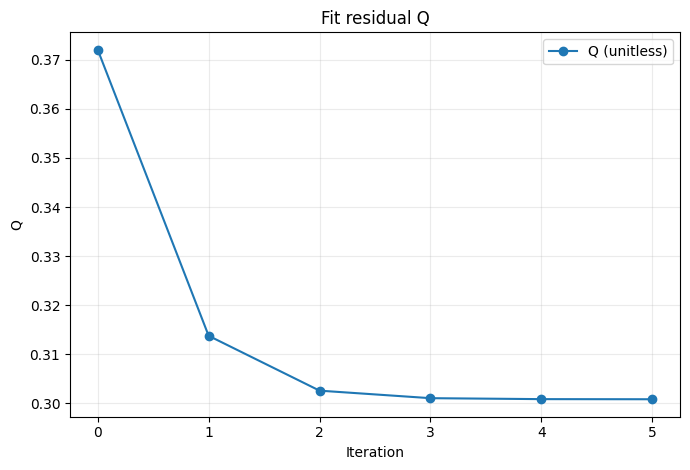

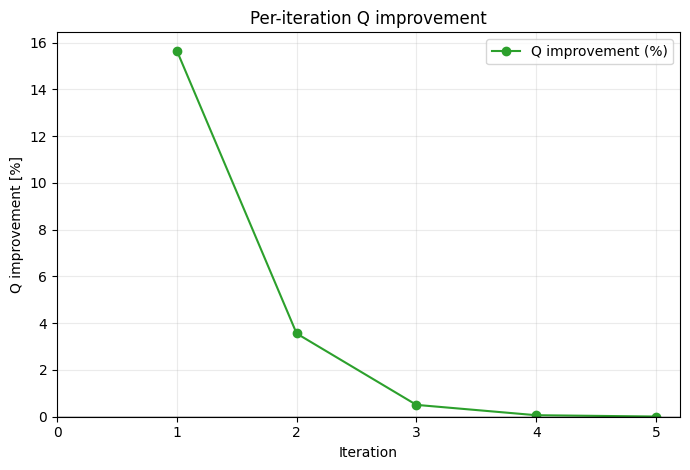

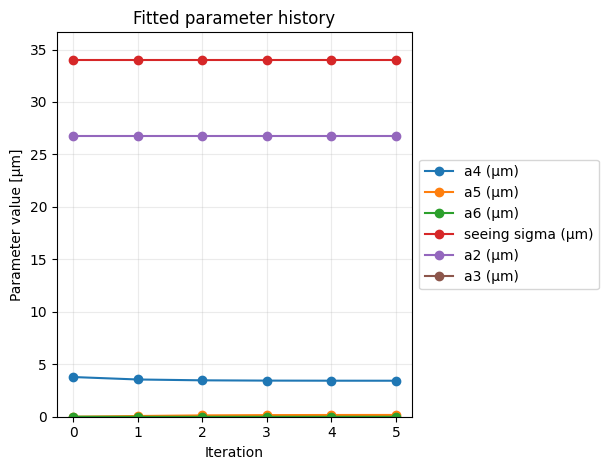

Saved q history graph to: result/fit_astigmatism_true_q_history.png
Saved q_improvement history graph to: result/fit_astigmatism_true_q_improvement_history.png
Saved parameters history graph to: result/fit_astigmatism_true_parameter_history.png


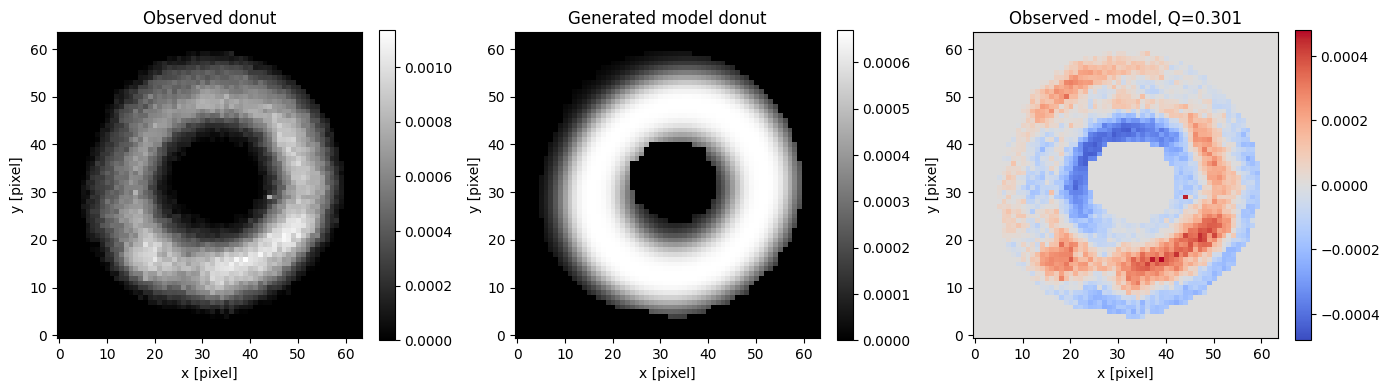


Final fitted parameters
seeing_sigma_px : 2.5216397
dx_px           : 1.9800345
dy_px           : -1.3279816
a4_mm           : 0.0034306276 mm  (3.431 um)
a5_mm           : 0.0001679249 mm  (0.168 um)
a6_mm           : -0.0000044130 mm  (-0.004 um)


In [210]:
# Run the DONUT iteration with astigmatism fitting enabled.
# a5_mm and a6_mm start at 0, then the algorithm may change them if the observed donut needs astigmatism.
fitted_params_astig, fit_history_astig, fitted_model_astig = donut_algorithm(
    fit_astigmatism=True,
)


DONUT Appendix-A iteration
Fitting parameters: ['seeing_sigma_px', 'dx_px', 'dy_px', 'a4_mm']
Initial Q: 0.372019
Convergence tolerance: 0.0100% relative Q improvement
Saving iteration donut graphs to: /Users/steven/DevLocal/Praktika/donut_method/result
Iteration 00 | Q=0.372019 | dQ=   n/a | Q improvement=   n/a | a4=3.784 um | a5=0.000 um | a6=0.000 um
Iteration 01 | Q=0.316996 | dQ=-0.055023 | Q improvement=+14.7904% | accepted | a4=3.552 um | a5=0.000 um | a6=0.000 um
Iteration 02 | Q=0.308612 | dQ=-0.008384 | Q improvement=+2.6449% | accepted | a4=3.476 um | a5=0.000 um | a6=0.000 um
Iteration 03 | Q=0.307644 | dQ=-0.000967 | Q improvement=+0.3135% | accepted | a4=3.452 um | a5=0.000 um | a6=0.000 um
Iteration 04 | Q=0.307534 | dQ=-0.000110 | Q improvement=+0.0358% | accepted | a4=3.444 um | a5=0.000 um | a6=0.000 um
Iteration 05 | Q=0.307521 | dQ=-0.000014 | Q improvement=+0.0044% | accepted | a4=3.441 um | a5=0.000 um | a6=0.000 um
Stopping: Q improved by only 0.00440%, below th

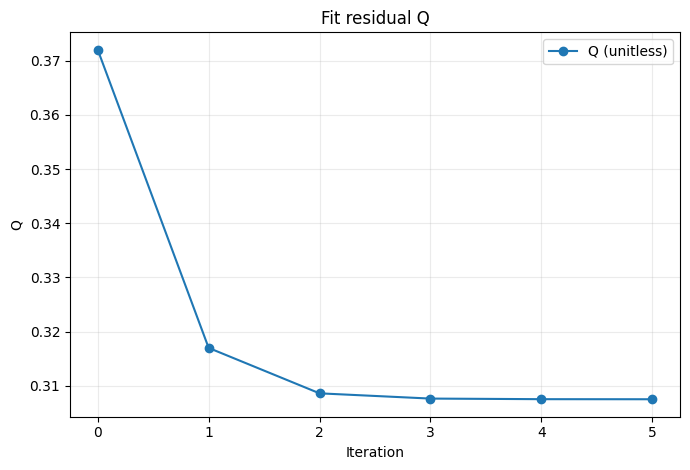

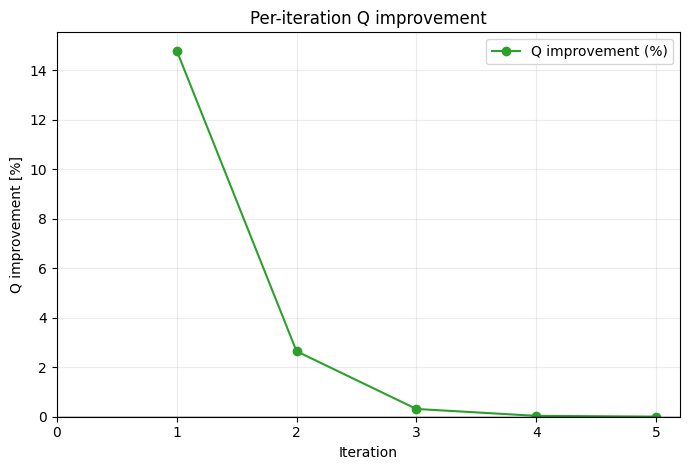

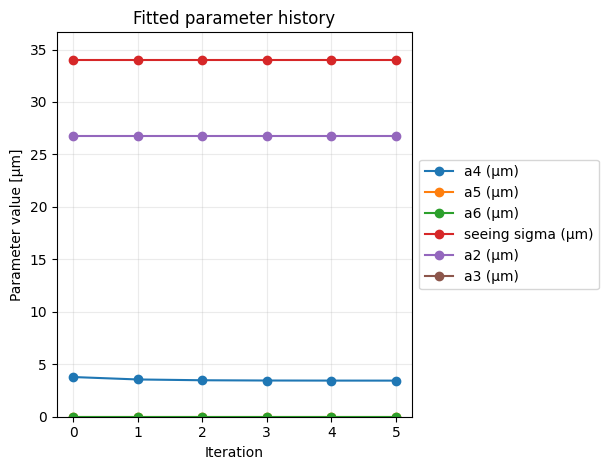

Saved q history graph to: result/fit_astigmatism_false_q_history.png
Saved q_improvement history graph to: result/fit_astigmatism_false_q_improvement_history.png
Saved parameters history graph to: result/fit_astigmatism_false_parameter_history.png


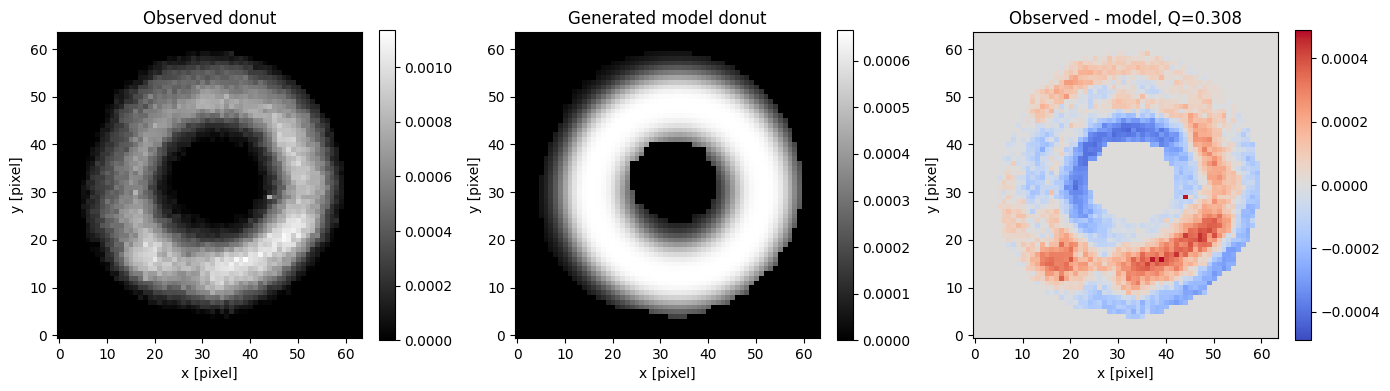


Final fitted parameters
seeing_sigma_px : 2.5216397
dx_px           : 1.9800345
dy_px           : -1.3279816
a4_mm           : 0.0034409776 mm  (3.441 um)
a5_mm           : 0.0000000000 mm  (0.000 um)
a6_mm           : 0.0000000000 mm  (0.000 um)


In [211]:
# Run the DONUT iteration with astigmatism fixed to zero.
# This is useful as a comparison model: only seeing, shift, and defocus are fitted.
fitted_params_no_astig, fit_history_no_astig, fitted_model_no_astig = donut_algorithm(
    fit_astigmatism=False,
)


Initial model comparison
Current start, a5=a6=0                     : Q = 0.372019
Calculated a5/a6, real eta=0.4167       : Q = 1.865898
Calculated a5/a6, no secondary eta=0       : Q = 1.892491
a5 calculated                              : 0.0053956821 mm = 5.396 µm
a6 calculated                              : -0.0017015505 mm = -1.702 µm


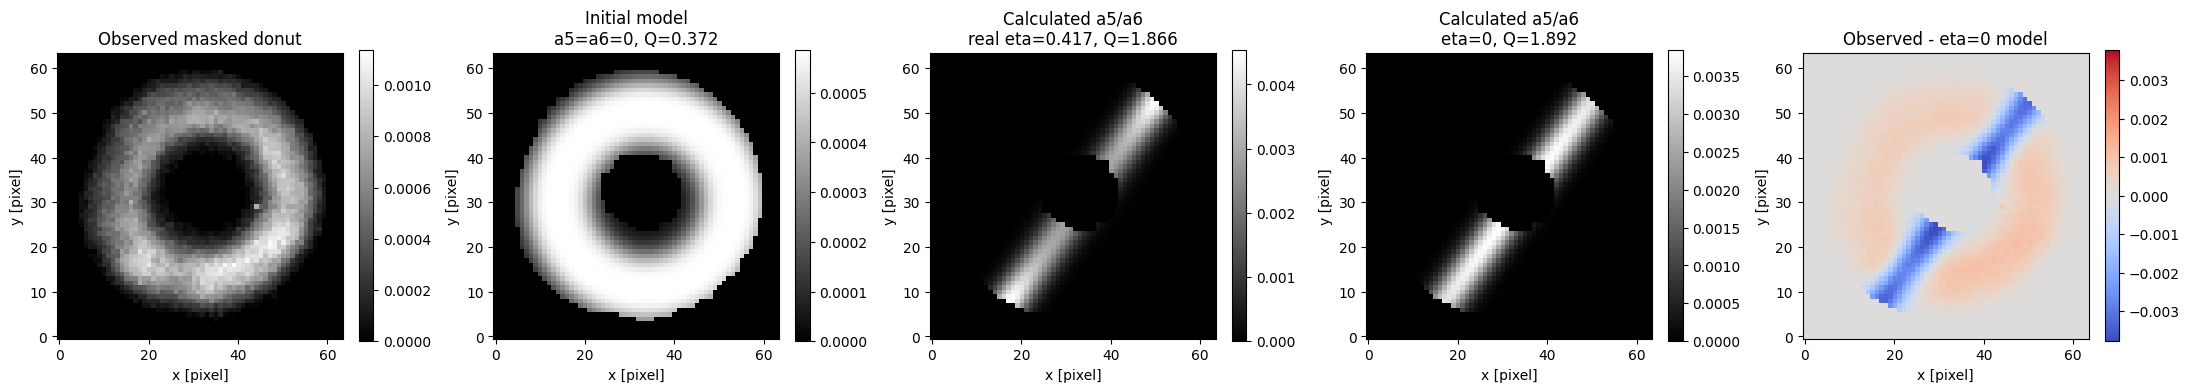

In [213]:
# Show the initial model if we use the moment-calculated astigmatism values.
# Current DONUT iteration starts with a5_mm = 0 and a6_mm = 0.
# This visualization also includes a special eta=0 model, meaning the pupil does NOT
# include the secondary-mirror obstruction. This is only for showing the elongated shape.
def render_model_with_eta(params, custom_eta, fit_mask=None):
    """Render the same forward model, but with a custom central obstruction eta."""
    custom_pupil = (rho_norm <= 1.0) & (rho_norm >= custom_eta)

    custom_Z4 = np.where(custom_pupil, np.sqrt(3.0) * (2.0 * rho_norm**2 - 1.0), 0.0)
    custom_Z5 = np.where(custom_pupil, np.sqrt(6.0) * rho_norm**2 * np.sin(2.0 * theta), 0.0)
    custom_Z6 = np.where(custom_pupil, np.sqrt(6.0) * rho_norm**2 * np.cos(2.0 * theta), 0.0)

    wavefront_mm = (
        params.get("a4_mm", 0.0) * custom_Z4
        + params.get("a5_mm", 0.0) * custom_Z5
        + params.get("a6_mm", 0.0) * custom_Z6
    )

    phase = 2.0 * np.pi * wavefront_mm / lambda_mm
    complex_pupil = custom_pupil.astype(float) * np.exp(1j * phase)

    field = np.fft.fftshift(
        np.fft.fft2(
            np.fft.ifftshift(complex_pupil)
        )
    )
    image_fft = np.abs(field)**2
    image_fft /= image_fft.sum()

    image_window = center_crop_square(image_fft, detector_window_fft_px)
    target_over_shape = (
        detector_shape[0] * detector_oversampling,
        detector_shape[1] * detector_oversampling,
    )
    zoom_factors = (
        target_over_shape[0] / image_window.shape[0],
        target_over_shape[1] / image_window.shape[1],
    )
    image_over = zoom(image_window, zoom_factors, order=1)
    image_over = match_shape_centered(image_over, target_over_shape)
    image_over = np.clip(image_over, 0.0, None)
    image_over /= image_over.sum()

    seeing_sigma_over = params.get("seeing_sigma_px", 0.0) * detector_oversampling
    if seeing_sigma_over > 0:
        image_over = gaussian_filter(
            image_over,
            sigma=seeing_sigma_over,
            mode="constant",
            cval=0.0,
        )
        image_over /= image_over.sum()

    model_det = bin_oversampled_to_detector(image_over, detector_oversampling)
    model_det = nd_shift(
        model_det,
        shift=(params.get("dy_px", 0.0), params.get("dx_px", 0.0)),
        order=3,
        mode="constant",
        cval=0.0,
        prefilter=True,
    )
    model_det = np.clip(model_det, 0.0, None)

    norm = model_det.sum() if fit_mask is None else model_det[fit_mask].sum()
    if norm <= 0 or not np.isfinite(norm):
        raise RuntimeError("Invalid model normalization.")
    return model_det / norm


calculated_astig_start_params = dict(donut_start_params)
calculated_astig_start_params["a5_mm"] = a5_0
calculated_astig_start_params["a6_mm"] = a6_0

zero_astig_initial_model = render_model(donut_start_params, fit_mask=fit_mask)
calculated_astig_annular_model = render_model(calculated_astig_start_params, fit_mask=fit_mask)
calculated_astig_no_secondary_model = render_model_with_eta(
    calculated_astig_start_params,
    custom_eta=0.0,
    fit_mask=fit_mask,
)

zero_astig_initial_masked = np.where(fit_mask, zero_astig_initial_model, 0.0)
calculated_astig_annular_masked = np.where(fit_mask, calculated_astig_annular_model, 0.0)
calculated_astig_no_secondary_masked = np.where(fit_mask, calculated_astig_no_secondary_model, 0.0)
no_secondary_residual = obs_norm - calculated_astig_no_secondary_masked

q_zero_astig = relative_residual_q(obs_norm, zero_astig_initial_model, fit_mask)
q_calculated_astig_annular = relative_residual_q(obs_norm, calculated_astig_annular_model, fit_mask)
q_calculated_astig_no_secondary = relative_residual_q(obs_norm, calculated_astig_no_secondary_model, fit_mask)

print("Initial model comparison")
print(f"Current start, a5=a6=0                     : Q = {q_zero_astig:.6f}")
print(f"Calculated a5/a6, real eta={eta:.4f}       : Q = {q_calculated_astig_annular:.6f}")
print(f"Calculated a5/a6, no secondary eta=0       : Q = {q_calculated_astig_no_secondary:.6f}")
print(f"a5 calculated                              : {a5_0:.10f} mm = {a5_0 * 1000:.3f} µm")
print(f"a6 calculated                              : {a6_0:.10f} mm = {a6_0 * 1000:.3f} µm")

lim = np.nanmax(np.abs(no_secondary_residual[fit_mask]))
if not np.isfinite(lim) or lim == 0:
    lim = 1.0

fig, ax = plt.subplots(1, 5, figsize=(22, 4))

im0 = ax[0].imshow(obs_norm, origin="lower", cmap="gray")
ax[0].set_title("Observed masked donut")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(zero_astig_initial_masked, origin="lower", cmap="gray")
ax[1].set_title(f"Initial model\na5=a6=0, Q={q_zero_astig:.3f}")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(calculated_astig_annular_masked, origin="lower", cmap="gray")
ax[2].set_title(f"Calculated a5/a6\nreal eta={eta:.3f}, Q={q_calculated_astig_annular:.3f}")
plt.colorbar(im2, ax=ax[2], fraction=0.046)

im3 = ax[3].imshow(calculated_astig_no_secondary_masked, origin="lower", cmap="gray")
ax[3].set_title(f"Calculated a5/a6\neta=0, Q={q_calculated_astig_no_secondary:.3f}")
plt.colorbar(im3, ax=ax[3], fraction=0.046)

im4 = ax[4].imshow(
    no_secondary_residual,
    origin="lower",
    cmap="coolwarm",
    vmin=-lim,
    vmax=lim,
)
ax[4].set_title("Observed - eta=0 model")
plt.colorbar(im4, ax=ax[4], fraction=0.046)

for axis in ax:
    axis.set_xlabel("x [pixel]")
    axis.set_ylabel("y [pixel]")

plt.tight_layout()
plt.show()
